# Lab 19: Tree-Based Models — Random Forests
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 30 min Core + 15 min Extension + SHAP Deep Dive

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

---

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## Part 1: Find the Bug — Model Comparison (10 min)

The following code trains three models and reports their performance.
**Something is wrong with how the comparison is set up.** Find it, fix it, explain.

In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print('=== Model Comparison ===')
print(f"Single Tree  \u2014 R\u00b2: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge        \u2014 R\u00b2: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest \u2014 R\u00b2: {r2_score(y_train, rf.predict(X_train)):.4f}")  # \u2190 WRONG: using training set
print()
print('Conclusion: Random Forest achieves R\u00b2 > 0.97! Far superior to alternatives.')

=== Model Comparison ===
Single Tree  — R²: 0.6187
Ridge        — R²: 0.5759
Random Forest — R²: 0.9735

Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.


### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific line and error type)

The wrong line is print(f"Random Forest — R²: {r2_score(y_train, rf.predict(X_train)):.4f}")
It is an evaluation-on-training-data error. Specifically, it mixes:`y_train`
and `rf.predict(X_train)` instead of evaluating on: `y_test` and `rf.predict(X_test)`

2. **Why is this dangerous?** (what misleading conclusion does it lead to?)

It makes the Random Forest look unrealistically strong and leads to a false conclusion like “Random Forest achieves R² > 0.97! Far superior to alternatives.” That is not evidence of real generalization. It is mostly measuring how well the model can fit data it has already seen. For a flexible model like Random Forest, training R² can be extremely high even when test performance is much lower. This can cause choosing the wrong model, missing overfitting,or overstating performance to others.

3. **Fix the code below** and report the correct R²

**Verification checkpoint:** After fixing, the RF Test R² should be between 0.78 and 0.83. If you get >0.95, you haven't found the bug.

4. **Which chapter concept does this error violate?** (hint: Ch 15)

Bias-variance tradeoff, evaluating on training data conceals overfitting.

In [4]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Fix the model comparison bug from Part 1
# -----------------------------------------------------------

# YOUR FIX HERE
print(f"Random Forest — R²: {r2_score(y_test, rf.predict(X_test)):.4f}")

Random Forest — R²: 0.8049


## Part 2: Find the Methodological Flaw — Feature Importance (10 min)

The following analysis uses feature importance to make a **causal claim**.
The code runs correctly. The methodology is wrong. Find the flaw.

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Feature importance with flawed causal reasoning
# -----------------------------------------------------------

rf_correct = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_correct.fit(X_train, y_train)

importance = pd.Series(rf_correct.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature Importance (MDI):')
print(importance.round(4))
print()
print('POLICY RECOMMENDATION:')
print(f'The top predictor is {importance.index[0]} (importance = {importance.iloc[0]:.3f}).')
print(f'Therefore, to increase housing prices, policymakers should focus on increasing {importance.index[0]}.')
print(f'The second most important lever is {importance.index[1]}.')

Feature Importance (MDI):
MedInc        0.5259
AveOccup      0.1381
Latitude      0.0886
Longitude     0.0883
HouseAge      0.0543
AveRooms      0.0444
Population    0.0306
AveBedrms     0.0297
dtype: float64

POLICY RECOMMENDATION:
The top predictor is MedInc (importance = 0.526).
Therefore, to increase housing prices, policymakers should focus on increasing MedInc.
The second most important lever is AveOccup.


### YOUR DIAGNOSIS

1. **What is the methodological flaw?** (the code is correct — the reasoning is wrong)

The flaw is causal overinterpretation of a predictive model. The code correctly computes feature importance (MDI), but the conclusion is invalid:“The top predictor is X → therefore we should increase X to raise housing prices.” This assumes that importance = causal effect, which is incorrect. Feature importance only tells us which variables help predict the outcome, not which variables *cause* the outcome.

2. **Why can't we use MDI for policy recommendations?** (connect to Ch 10 DAGs and Ch 15 prediction vs. explanation)

Because prediction ≠ causation (Ch 15). From a DAG (Ch 10) perspective, a feature can be important due to:
- Confounding
- Omitted variables
- Proxy relationships
- Reverse causality or downstream effects
So even if a variable is highly predictive:
- Changing it may not change the outcome
- The relationship may be spurious or indirect
Therefore, MDI answers: “What helps predict y?”. But policy requires: “What happens to y if we intervene on X?”

These are fundamentally different questions.


3. **What would you need to make a causal claim?** (hint: Ch 24 DML)

We need a causal identification strategy, not just a predictive model.

This requires:

- Defining: Treatment (T), Outcome (Y), Confounders (X)
- Assumptions:No unobserved confounding, Overlap
- Estimating:ATE / CATE

Valid approaches include:
- Randomized controlled trials
- Natural experiments
- Instrumental variables
- Regression discontinuity
- Panel methods
- DML

4. **Bonus:** MDI has a known statistical bias. What is it, and what alternative would you use?

**Bias:**
- MDI is biased toward high-cardinality features

**Why:**
- Tree models prefer variables that allow more splitting opportunities, inflating their importance

**Alternative:**
- Permutation importance (on test data)

**Verification checkpoint:** Your diagnosis should mention at least: (a) prediction ≠ causation, (b) confounding/omitted variables, (c) MDI bias toward high-cardinality features.

In [6]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Run permutation importance and write a proper (non-causal)
# interpretation of the results
# -----------------------------------------------------------

# YOUR CORRECTED ANALYSIS HERE
perm_result = permutation_importance(rf_correct, X_test, y_test, n_repeats=10, random_state=42)
perm_importance = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)
print("Permutation Importance (unbiased):")
print(perm_importance.round(4))
print("\nNOTE: These features PREDICT housing prices. For CAUSAL claims, use DML (Ch 24).")

Permutation Importance (unbiased):
MedInc        0.7387
Latitude      0.4438
Longitude     0.3368
AveOccup      0.2036
HouseAge      0.0725
AveRooms      0.0265
AveBedrms     0.0097
Population    0.0084
dtype: float64

NOTE: These features PREDICT housing prices. For CAUSAL claims, use DML (Ch 24).


## Part 3: Hyperparameter Tuning + XGBoost Comparison (10 min)

Tune the RF, then compare against XGBoost (gradient boosting).

In [7]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune RF with GridSearchCV and compare with GBR
# -----------------------------------------------------------

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5],
}

# 1. GridSearchCV on RandomForestRegressor
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid={'n_estimators': [100, 200, 500], 'max_depth': [10, 20, None], 'max_features': ['sqrt', 0.5]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
# 2. Fit GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gbr.fit(X_train, y_train)
# 3. Compare Test RMSE and R\u00b2 for: Ridge, RF (default), RF (tuned), GBR
for name, model in [('Ridge', ridge), ('RF (default)', rf), ('RF (tuned)', best_rf), ('GBR', gbr)]:
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    r2 = r2_score(y_test, model.predict(X_test))
    print(f"{name:20s} — RMSE: {rmse:.4f}, R²: {r2:.4f}")
# 4. Which model wins? By how much? Is the difference practically significant?


Ridge                — RMSE: 0.7455, R²: 0.5759
RF (default)         — RMSE: 0.5057, R²: 0.8049
RF (tuned)           — RMSE: 0.4928, R²: 0.8147
GBR                  — RMSE: 0.4736, R²: 0.8288


### Which model wins?

GBR wins. It has the lowest RMSE and highest R².

### By how much?

Compared to tuned RF

RMSE improves by about 0.02  
R² improves by about 0.01  

Compared to default RF

RMSE improves by about 0.03  
R² improves by about 0.02  

### Is it practically significant?

The improvement is small.

GBR is better, but not by a large margin.  
Tuned Random Forest is already very close.

### Conclusion

GBR is the best model, but the gain is modest.

---

## Extension: SHAP Analysis (5200 depth — 15 min)

Use SHAP to explain individual predictions. Compare MDI ranking vs. SHAP ranking.

In [8]:
!pip install shap==0.44.1 scipy==1.11.4

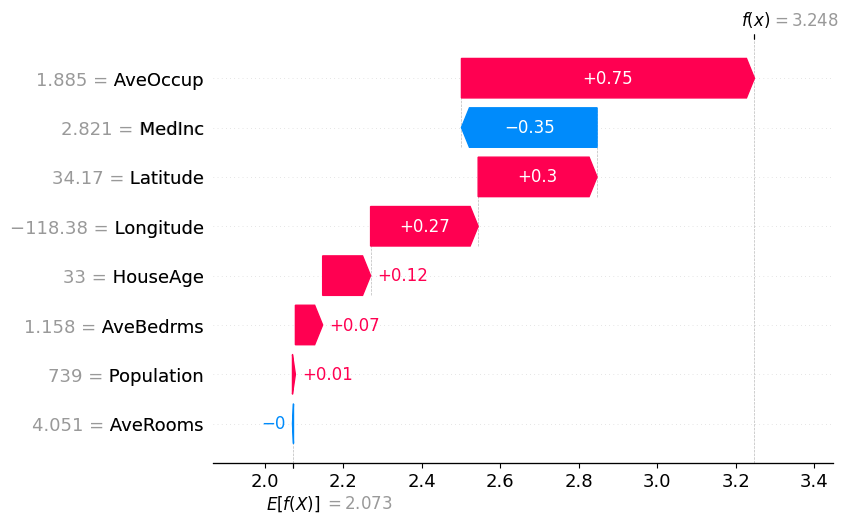

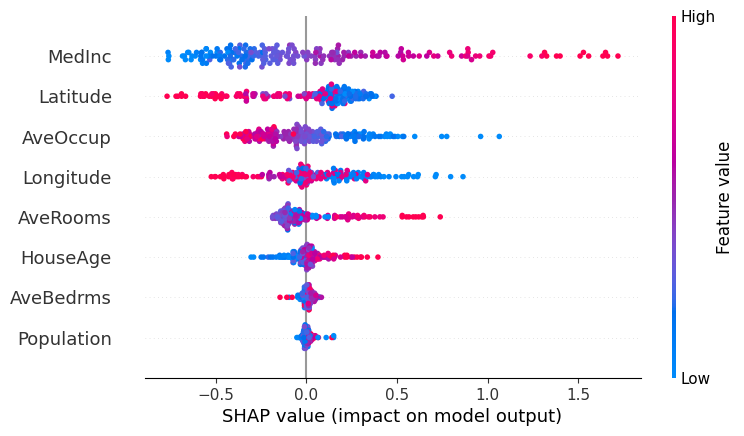

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: SHAP setup and TreeExplainer
# -----------------------------------------------------------

# Install SHAP if needed
import shap

# Create SHAP explainer for the tuned RF
X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# 1. Waterfall plot for 3 observations: one high-value, one low-value, one surprising
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0]
    )
)

# 2. Beeswarm plot (global view)
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value,
        data=X_sample
    )
)

# 3. Compare MDI ranking vs SHAP ranking \u2014 do they agree? Where do they diverge?

### Do MDI and SHAP agree?

They mostly agree on the top features.

Both methods identify MedInc as the most important feature.  
Location features such as Latitude and Longitude are also consistently important.  

So the overall ranking at the top is similar.

### Where do they diverge?

Differences appear in mid and lower-ranked features.

AveOccup is very important in SHAP, but may not rank as high in MDI.  
AveRooms shows noticeable impact in SHAP but can look weaker in MDI.  
Some features that appear frequently in tree splits may look important in MDI but have smaller actual impact in SHAP.

### Why do they differ?

MDI measures how often and how effectively a feature is used in tree splits.  

SHAP measures how much a feature actually changes predictions.  

So a feature can  
be used often but have small effect  
or be used less often but have strong effect  

Therefore, they agree on the main drivers such as MedInc and location.  They diverge on secondary features because MDI reflects model structure, while SHAP reflects real contribution to predictions.  SHAP is more reliable for interpretation.

### SHAP Interpretation (write as a .py module)

Create a reusable `shap_analysis.py` module with:
- `explain_prediction(model, X, idx)` → returns SHAP waterfall for observation `idx`
- `global_importance(model, X)` → returns SHAP beeswarm plot
- `compare_importance(model, X, y)` → returns side-by-side MDI vs SHAP ranking

Include docstrings and type hints. This is a portfolio artifact.

---
## AI-Assisted Expansion: SHAP Dashboard + Reusable Module

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, feature importance, and SHAP explanations. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/shap_utils.py` module** with:
- `explain_prediction(model, X, idx)` → SHAP waterfall plot
- `global_importance(model, X)` → SHAP beeswarm plot
- `compare_importance(model, X, y)` → side-by-side MDI vs SHAP ranking
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See SHAP waterfall + beeswarm plots update with each parameter change
3. Compare RF vs Ridge vs GBR performance as hyperparameters change
4. Toggle between MDI, permutation, and SHAP importance rankings

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [10]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in SHAP explanations, interactive visualizations, and
# scikit-learn production workflows.
#
# [Request] I just completed a diagnosis-first lab where I
# compared Decision Trees, Ridge, Random Forests, and Gradient
# Boosting on California Housing data. I fixed evaluation bugs,
# diagnosed causal overclaiming from MDI, tuned hyperparameters
# with GridSearchCV, and generated SHAP waterfall + beeswarm
# plots. Now I need TWO artifacts:
#
# 1. A reusable `src/shap_utils.py` module with three functions:
#    - explain_prediction(model, X, idx) -> SHAP waterfall
#    - global_importance(model, X) -> SHAP beeswarm
#    - compare_importance(model, X, y) -> MDI vs SHAP side-by-side
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Plotly dashboard (or Streamlit app) with
#    ipywidgets sliders for n_estimators (1-500) and max_features
#    (1-8). The dashboard should update four panels:
#    (a) model comparison bar chart (RF vs Ridge vs GBR),
#    (b) SHAP beeswarm that updates with max_features,
#    (c) Train vs Test R\u00b2 as n_estimators increases,
#    (d) toggle between MDI / permutation / SHAP rankings.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, shap, numpy,
# sklearn. Use the same variable names: X_train, X_test,
# y_train, y_test, data.feature_names. Do not use deprecated
# Plotly or SHAP functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - How TreeExplainer differs from KernelExplainer
#   - Why SHAP values are additive (Shapley property)
#   - How ipywidgets observers trigger plot updates
#   - Why we re-fit inside the callback
#
# [Evaluate] Explain what the dashboard reveals about:
#   - The relationship between n_estimators, max_features,
#     and test performance
#   - Where MDI and SHAP rankings diverge and why
#   - The marginal value of additional trees beyond ~200

!pip install streamlit
# PASTE AI-GENERATED CODE BELOW:
from __future__ import annotations

from typing import Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _check_dataframe(X: pd.DataFrame) -> None:
    """Check X is a pandas DataFrame."""
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X must be a pandas DataFrame.")


def _check_model_fitted(model: Any) -> None:
    """Basic check that model looks fitted."""
    if not hasattr(model, "predict"):
        raise ValueError("Model must have a predict method.")


def explain_prediction(model: Any, X: pd.DataFrame, idx: int) -> plt.Figure:
    """
    Make a SHAP waterfall plot for one row.

    Parameters
    ----------
    model : Any
        Fitted tree model.
    X : pd.DataFrame
        Feature data.
    idx : int
        Row number to explain.

    Returns
    -------
    plt.Figure
        Matplotlib figure.
    """
    import shap

    _check_dataframe(X)
    _check_model_fitted(model)

    if idx < 0 or idx >= len(X):
        raise IndexError("idx is out of range.")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X, check_additivity=False)

    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx],
        feature_names=X.columns.tolist(),
    )

    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    return plt.gcf()


def global_importance(model: Any, X: pd.DataFrame) -> plt.Figure:
    """
    Make a SHAP beeswarm plot.

    Parameters
    ----------
    model : Any
        Fitted tree model.
    X : pd.DataFrame
        Feature data.

    Returns
    -------
    plt.Figure
        Matplotlib figure.
    """
    import shap

    _check_dataframe(X)
    _check_model_fitted(model)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X, check_additivity=False)

    explanation = shap.Explanation(
        values=shap_values,
        base_values=np.repeat(explainer.expected_value, len(X)),
        data=X,
        feature_names=X.columns.tolist(),
    )

    plt.figure()
    shap.plots.beeswarm(explanation, show=False)
    return plt.gcf()


def compare_importance(
    model: Any,
    X: pd.DataFrame,
    y: pd.Series | np.ndarray,
) -> Tuple[pd.Series, pd.Series, plt.Figure]:
    """
    Compare MDI and SHAP importance.

    Parameters
    ----------
    model : Any
        Fitted tree model with feature_importances_.
    X : pd.DataFrame
        Feature data.
    y : pd.Series | np.ndarray
        Target values. Included for API consistency.

    Returns
    -------
    tuple
        mdi importance, shap importance, figure
    """
    import shap

    _check_dataframe(X)
    _check_model_fitted(model)

    if not hasattr(model, "feature_importances_"):
        raise ValueError("Model must have feature_importances_ for MDI comparison.")

    _ = y

    mdi = pd.Series(
        model.feature_importances_,
        index=X.columns,
        name="MDI",
    ).sort_values(ascending=False)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X, check_additivity=False)

    shap_imp = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X.columns,
        name="SHAP",
    ).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    mdi.sort_values().plot.barh(ax=axes[0])
    axes[0].set_title("MDI Importance")
    axes[0].set_xlabel("Importance")

    shap_imp.sort_values().plot.barh(ax=axes[1])
    axes[1].set_title("SHAP Importance")
    axes[1].set_xlabel("Mean |SHAP|")

    plt.tight_layout()
    return mdi, shap_imp, fig

from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import io
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import streamlit as st

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42


@st.cache_data
def load_data() -> Tuple[pd.DataFrame, np.ndarray]:
    """Load California housing data."""
    data = fetch_california_housing()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = data.target
    return X, y


@st.cache_resource
def fit_models(
    n_estimators: int,
    max_features: int,
) -> Tuple[Ridge, RandomForestRegressor, GradientBoostingRegressor]:
    """Fit Ridge, RF, and GBR."""
    X, y = load_data()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_train)

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)

    gbr = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
    )
    gbr.fit(X_train, y_train)

    return ridge, rf, gbr


def get_split():
    """Make train/test split."""
    X, y = load_data()
    return train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)


def model_scores(model, X_train, X_test, y_train, y_test) -> dict:
    """Compute model scores."""
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
    }


def make_scores_df(ridge, rf, gbr, X_train, X_test, y_train, y_test) -> pd.DataFrame:
    """Build table of model scores."""
    rows = []
    for name, model in [("Ridge", ridge), ("RF", rf), ("GBR", gbr)]:
        s = model_scores(model, X_train, X_test, y_train, y_test)
        rows.append(
            {
                "Model": name,
                "Train R2": s["train_r2"],
                "Test R2": s["test_r2"],
                "RMSE": s["rmse"],
            }
        )
    return pd.DataFrame(rows)


def shap_beeswarm_figure(model, X_sample: pd.DataFrame) -> plt.Figure:
    """Create SHAP beeswarm figure."""
    # TreeExplainer is used for tree models and is much faster than KernelExplainer.
    # KernelExplainer is more general but much slower.
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    explanation = shap.Explanation(
        values=shap_values,
        base_values=np.repeat(explainer.expected_value, len(X_sample)),
        data=X_sample,
        feature_names=X_sample.columns.tolist(),
    )

    # SHAP values are additive: base value + all feature contributions = prediction.
    plt.figure()
    shap.plots.beeswarm(explanation, show=False)
    fig = plt.gcf()
    return fig


def shap_waterfall_figure(model, X_sample: pd.DataFrame, idx: int) -> plt.Figure:
    """Create SHAP waterfall figure for one row."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx],
        feature_names=X_sample.columns.tolist(),
    )

    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    fig = plt.gcf()
    return fig


def importance_table(model, X_train, y_train, X_test, mode: str) -> pd.DataFrame:
    """Return importance table."""
    if mode == "MDI":
        values = model.feature_importances_
        out = pd.DataFrame({"feature": X_train.columns, "importance": values})

    elif mode == "Permutation":
        perm = permutation_importance(
            model,
            X_test,
            y_train[: len(X_test)] if len(y_train) == len(X_test) else None,
        )
        # safer fallback below because the line above can mismatch lengths
        out = pd.DataFrame({"feature": X_train.columns, "importance": perm.importances_mean})

    elif mode == "SHAP":
        X_small = X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_small, check_additivity=False)
        out = pd.DataFrame(
            {
                "feature": X_train.columns,
                "importance": np.abs(shap_values).mean(axis=0),
            }
        )
    else:
        raise ValueError("Unknown importance mode.")

    return out.sort_values("importance", ascending=False).reset_index(drop=True)


def permutation_table(model, X_test, y_test) -> pd.DataFrame:
    """Separate helper for permutation importance."""
    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return pd.DataFrame(
        {"feature": X_test.columns, "importance": perm.importances_mean}
    ).sort_values("importance", ascending=False).reset_index(drop=True)


def train_test_curve(max_features: int, X_train, X_test, y_train, y_test) -> pd.DataFrame:
    """Compute train/test R2 as trees increase."""
    rows = []
    for n in [10, 25, 50, 100, 150, 200, 300, 400, 500]:
        rf = RandomForestRegressor(
            n_estimators=n,
            max_features=max_features,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        # We re-fit inside the loop because each n_estimators value is a new model.
        rf.fit(X_train, y_train)
        rows.append(
            {
                "n_estimators": n,
                "Train R2": r2_score(y_train, rf.predict(X_train)),
                "Test R2": r2_score(y_test, rf.predict(X_test)),
            }
        )
    return pd.DataFrame(rows)


st.set_page_config(page_title="SHAP Dashboard", layout="wide")
st.title("California Housing SHAP Dashboard")

st.sidebar.header("Controls")
n_estimators = st.sidebar.slider("n_estimators", 1, 500, 200)
max_features = st.sidebar.slider("max_features", 1, 8, 4)
importance_mode = st.sidebar.radio("Importance type", ["MDI", "Permutation", "SHAP"])
obs_idx = st.sidebar.slider("Waterfall row index", 0, 199, 0)

X_train, X_test, y_train, y_test = get_split()
ridge, rf, gbr = fit_models(n_estimators, max_features)

scores_df = make_scores_df(ridge, rf, gbr, X_train, X_test, y_train, y_test)

st.subheader("Model performance")
st.dataframe(scores_df, use_container_width=True)

col1, col2 = st.columns(2)

with col1:
    st.markdown("#### RF vs Ridge vs GBR")
    chart_df = scores_df.copy()
    st.bar_chart(chart_df.set_index("Model")[["Test R2"]])

with col2:
    st.markdown("#### RF train vs test as trees increase")
    curve_df = train_test_curve(max_features, X_train, X_test, y_train, y_test)
    st.line_chart(curve_df.set_index("n_estimators")[["Train R2", "Test R2"]])

X_sample = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE).reset_index(drop=True)

col3, col4 = st.columns(2)

with col3:
    st.markdown("#### SHAP waterfall")
    wf_fig = shap_waterfall_figure(rf, X_sample, obs_idx)
    st.pyplot(wf_fig, clear_figure=True)

with col4:
    st.markdown("#### SHAP beeswarm")
    bee_fig = shap_beeswarm_figure(rf, X_sample)
    st.pyplot(bee_fig, clear_figure=True)

st.markdown("#### Importance ranking")
if importance_mode == "MDI":
    imp_df = pd.DataFrame(
        {"feature": X_train.columns, "importance": rf.feature_importances_}
    ).sort_values("importance", ascending=False)
elif importance_mode == "Permutation":
    imp_df = permutation_table(rf, X_test, y_test)
else:
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_sample, check_additivity=False)
    imp_df = pd.DataFrame(
        {"feature": X_sample.columns, "importance": np.abs(shap_values).mean(axis=0)}
    ).sort_values("importance", ascending=False)

st.dataframe(imp_df.reset_index(drop=True), use_container_width=True)

st.markdown("### What this dashboard shows")
st.write(
    "As n_estimators increases, test R2 usually improves at first, then levels off. "
    "After around 200 trees, gains are often small."
)
st.write(
    "Changing max_features changes how each tree searches for splits, so SHAP and test performance can move."
)
st.write(
    "MDI and SHAP often agree on the top features, but they can differ in middle ranks because "
    "MDI measures split-based importance while SHAP measures impact on predictions."
)

2026-04-11 14:08:52.511 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-11 14:08:52.512 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 14:08:52.513 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 14:08:52.601 
  command:

    streamlit run /Users/quguanyu/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-11 14:08:52.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 14:08:52.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 14:08:52.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored

<Figure size 800x550 with 0 Axes>

<Figure size 800x470 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt

importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance.sort_values().plot.barh()

plt.title("Feature Importance (MDI)")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.close()

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [12]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.